In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import hashlib
import json
import warnings
warnings.filterwarnings('ignore')

DEMONSTRATING DATA VALIDATION SUITE
 Loaded existing train/test data
   Train: 117 samples
   Test: 36 samples
Patient ID column: patient_id
Traget column: heart_disease_present
Checking 46 columns for auto-detection
slope_of_peak_exercise_st_segment: categorical(3) unique values
thal: categorival (object dtype)
resting_blood_pressure: numerical (28) unique values
chest_pain_type: categorical(4) unique values
num_major_vessels: categorical(4) unique values
fasting_blood_sugar_gt_120_mg_per_dl: categorical(2) unique values
resting_ekg_results: categorical(2) unique values
serum_cholesterol_mg_per_dl: numerical (84) unique values
oldpeak_eq_st_depression: numerical (32) unique values
sex: categorical(2) unique values
age: numerical (39) unique values
max_heart_rate_achieved: numerical (64) unique values
exercise_induced_angina: categorical(2) unique values
age_group: categorival (object dtype)
is_elderly: categorical(2) unique values
age_decade: categorical(6) unique values
bp_category: 

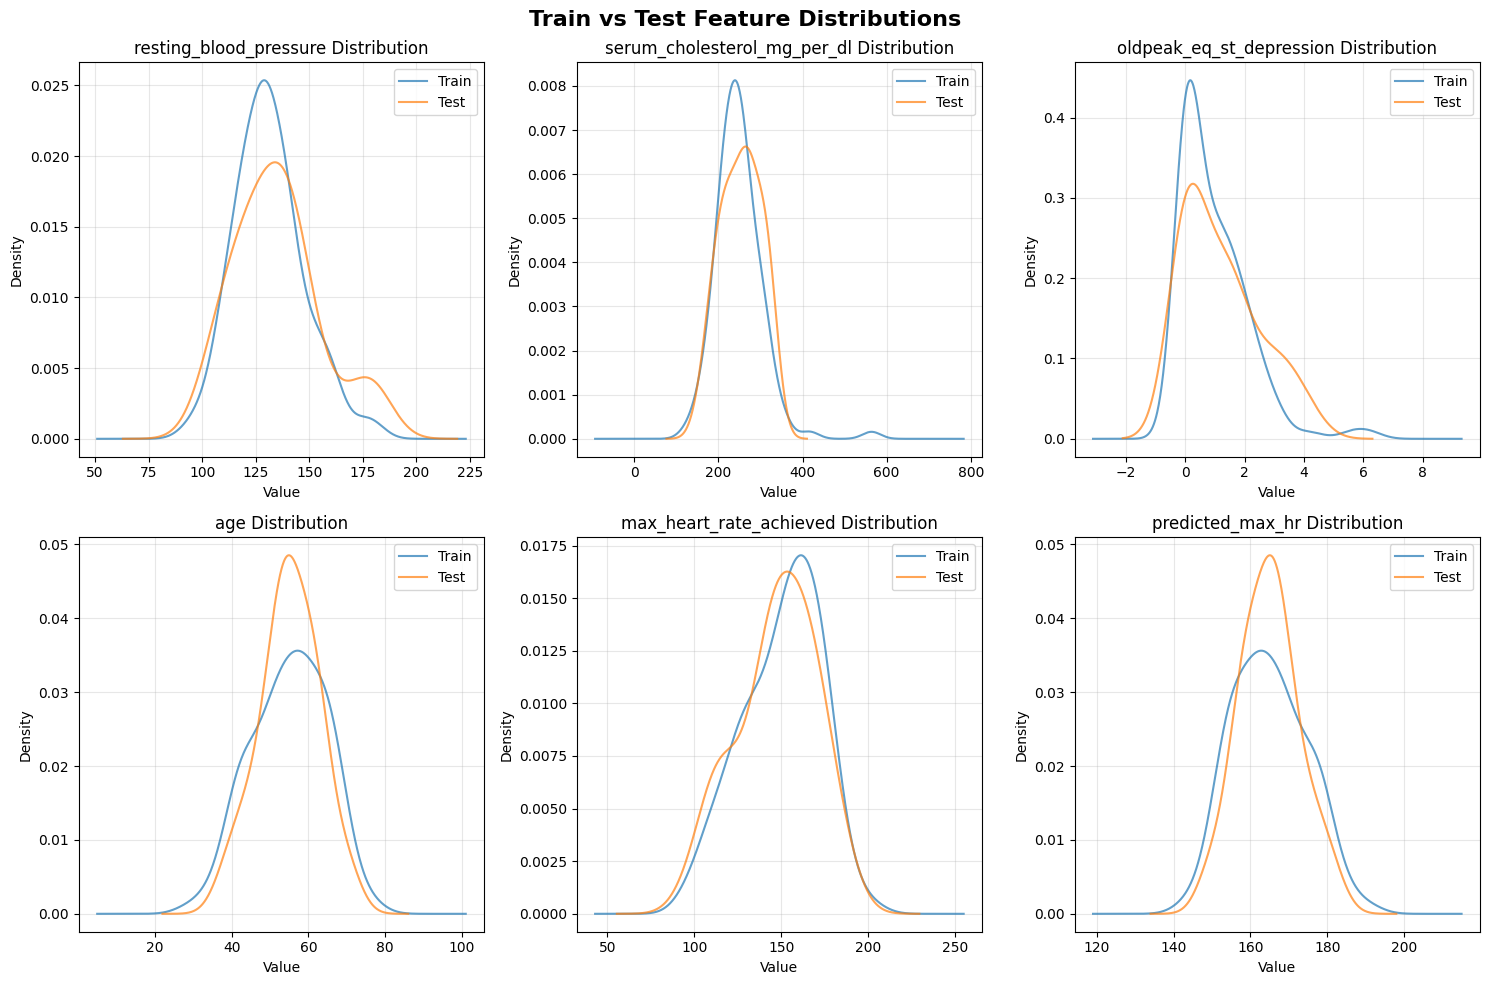


 DATA VALIDATION REPORT

 SUMMARY:
  Total Checks: 8
  Passed: 8
  Warnings: 3
  Critical Issues: 0

  VALIDATION PASSED WITH WARNINGS: 3 warning(s)
   Review warnings but can proceed with training.

 DETAILED RESULTS:

  Feature Consistency:
     All Column Present
     Data Types Consistent
     Value Ranges Valid
      Issues found:
      - Categorical value issues: [{'column': 'resting_ekg_results', 'new_categories': [1], 'count': 1}, {'column': 'simple_risk_score', 'new_categories': [0], 'count': 1}, {'column': 'metabolic_score', 'new_categories': [0], 'count': 1}]

  Data Leakage:
     No Patient Overlap
     No Temporal Leakage
     Target Distribution Ok
      Issues found:
      - High correlations: [{'feature_pair': 'resting_blood_pressure-bp_squared', 'train_correlation': 0.9962573864304518, 'test_correlation': 0.9960687344300232}, {'feature_pair': 'serum_cholesterol_mg_per_dl-cholesterol_squared', 'train_correlation': 0.9710337605836385, 'test_correlation': 0.9958456045344

In [28]:
class DataValidationSuite:
    # comprehensive data validation suite for heart disease predication ML
    #checking for deature consistenct, data leakage and stats properties

    def __init__(self, train_data,test_data,patient_id_col = 'patient_id',
                target_col = 'heart_disease_present',
                categorical_cols = None,
                numerical_cols = None):
        
        self.train_data = train_data.copy()
        self.test_data = test_data.copy()
        self.patient_id_col = patient_id_col
        self.target_col = target_col
        self.categorical_cols = categorical_cols if categorical_cols is not None else []
        self.numerical_cols = numerical_cols if numerical_cols is not None else []

        #auto-detect columns types just incase not provided
        self._auto_detect_column_types()
        if not self.categorical_cols and not self.numerical_cols:
            print("\n🔍 No columns specified, running auto-detection...")
            self._auto_detect_column_types()
        else:
            print(f"\n📊 Using provided columns:")
            print(f"   Categorical: {len(self.categorical_cols)} columns")
            print(f"   Numerical: {len(self.numerical_cols)} columns")

        # Storing validation results
        self.validation_results = {}
        self.validation_passed = True

        print("=" * 80)
        print("\n Data Validiation suite initlialised")
        print("=" * 80)
        print(f"Training samples: {len(train_data)}")
        print(f"Test samples: {len(test_data)}")
        print(f"Patient ID column: {patient_id_col}")
        print(f"Target column: {target_col}")

    def _auto_detect_column_types(self):
        # auto-detect categorical and numerical columns.

        print(f"Patient ID column: {self.patient_id_col}")
        print(f"Traget column: {self.target_col}")

        if self.categorical_cols is None:
            self.categorical_cols = []
        if self.numerical_cols is None:
            self.numerical_cols = []
        
        # Reset the list if we want to do a fresh auto-detection:
        if not self.categorical_cols or not self.numerical_cols:
            self.categorical_cols = []
            self.numerical_cols = []
        
        # Get all column except patient_id and target
        columns_to_check = [col for col in self.train_data.columns
                            if col not in [self.patient_id_col,self.target_col]]
        
        print(f"Checking {len(columns_to_check)} columns for auto-detection")

        for col in columns_to_check:
            #skip if they have being classified:
            if col in self.categorical_cols or col in self.numerical_cols:
                continue
            
            #Rule 1: Object dtype = catergorical
            if self.train_data[col].dtype == 'object':
                self.categorical_cols.append(col)
                print(f"{col}: categorival (object dtype)")
            
            # Rule 2: <= 10 unique values = categorical
            elif self.train_data[col].nunique() <= 10:
                self.categorical_cols.append(col)
                print(f"{col}: categorical({self.train_data[col].nunique()}) unique values")
            
            else:
                self.numerical_cols.append(col)
                print(f"{col}: numerical ({self.train_data[col].nunique()}) unique values")
        
        print("Auto-Detect results:")
        print(f"""Categorical Columns:{len(self.categorical_cols)}
                Numerical Columns: {len(self.numerical_cols)}
                Total Classified:{len(self.categorical_cols)+len(self.numerical_cols)}
                """)

        return self.categorical_cols,self.numerical_cols
    
    def run_full_validation(self):
        # Run all the validation checks 
        print("\n" + "=" * 80)
        print("Running complete data validation suite")
        print("=" * 80)

        # 1.Frature consistenct check
        print("\n Feature consistncy check")
        print('='*70)
        self.validate_feature_consistency()

        # 2. data leaky prevention checks
        print("\n Data leaky check")
        print("="*70)
        self.validate_data_leaky()

        # 3. stat properties checks
        print("\n Stats Properties checks")
        print("=" *70)
        self.validate_statistical_properties()

        #Generate summary report
        self.generate_validation_report()

        return self. validation_passed
    


    """======== 1. FEATURE CONSISTENCY CHECK =========="""

    def validate_feature_consistency(self):
        results = {
            'passed': True,
            'checks': {},
            'issues': []
        }

        print('\n Check for feature consistency...')

        #1. Expected columns present
        print("Check 1: All columns are present in both datasets")
        train_cols = set(self.train_data.columns)
        test_cols = set(self.test_data.columns)

        missing_in_train = test_cols - train_cols
        missing_in_test = train_cols - test_cols

        if(missing_in_test):
            results['passed'] = False
            results['issues'].append(f"Columns missing in test: {missing_in_test}")
            print(f"ERROR: Columns missing in test set: {missing_in_test}")
        else:
            results['checks']['all_column_present'] = True
            print(f"All {len(train_cols)} columns present in both datasets")
        
        if (missing_in_train):
            results['passed'] = False
            results['issues'].append(f"Columns missing in train: {missing_in_train}")
            print(f"ERROR: Columns missing in train set: {missing_in_train}")
        
        # validate types
        print('\n check 2: Data types consistency')
        dtype_issues = []

        common_cols = train_cols.intersection(test_cols)
        for col in common_cols:
            if (col not in [self.patient_id_col,self.target_col]):
                train_dtype = self.train_data[col].dtype
                test_dtype = self.test_data[col].dtype

                if train_dtype != test_dtype:
                    dtype_issues.append({
                        'column':col,
                        'train_dtype': str(train_dtype),
                        'test_dtype': str(test_dtype)
                    })
        
        if (dtype_issues):
            results['passed'] = False
            results['issues'].append(f"Data type mismatch: {dtype_issues}")
            print(f"ERROR: Data type mismatches found:")
            for issue in dtype_issues:
                print(f"        {issue['column']}: Train={issue['train_dtype']}, Test={issue['test_dtype']}")
        else:
            results['checks']['data_types_consistent'] = True
            print(f"All data types are consistent")
        
        # Check 3: Ensure value ranges are valid
        print("\nCheck 3: Valid value ranges")
        range_issues = []

        # Auto-detection run.
        if not self.numerical_cols and not self.categorical_cols:
            print("No columsn reached yet, running auto-detecting....")
            self._auto_detect_column_types

        # check for numerical columns
        for col in self.numerical_cols:
            if col in self.train_data.columns and col in self.test_data.columns:
                # check for null values 
                train_nan = self.train_data[col].isna().sum()
                test_nan = self.test_data[col].isna().sum()
                train_inf = np.isinf(self.train_data[col]).sum()
                test_inf = np.isinf(self.test_data[col]).sum()

                if train_nan > 0 or test_nan > 0 or train_inf > 0 or test_inf > 0:
                    range_issues.append ({
                        'column':col,
                        'train_nan': train_nan,
                        'test_nan': test_nan,
                        'train_inf': train_inf,
                        'test_inf': test_inf
                    })

        if range_issues:
            results['passed'] = False
            results['issues'].append(f"Value range issues: {range_issues}")
            print(f"WARNING: Value range issues found:")
            for issue in range_issues:
                if issue['train_nan'] > 0 or issue['test_nan'] > 0:
                    print(f"        {issue['column']}: NaN values - Train={issue['train_nan']}, Test={issue['test_nan']}")
                if issue['train_inf'] > 0 or issue['test_inf'] > 0:
                    print(f"        {issue['column']}: Infinite values - Train={issue['train_inf']}, Test={issue['test_inf']}")
        else:
            results['checks']['value_ranges_valid'] = True
            print(f"All value ranges are valid (no NaN/inf)")
    
        # Check 4: for categorical values consistency 
        print('\nCheck 4: Catergorical value consistency')
        categorical_issues = []

        for col in self.categorical_cols:
            if col in self.train_data.columns and col in self.test_data.columns:
                train_categories = set(self.train_data[col].dropna().unique())
                test_categories = set(self.test_data[col].dropna().unique())

                #check for categories in test that aren't in train 
                new_categories = test_categories - train_categories
                if new_categories:
                    categorical_issues.append({
                        'column': col,
                        'new_categories': list(new_categories),
                        'count': len(new_categories)
                    })
        if categorical_issues:
            results['passed'] = False
            results['issues'].append(f"Categorical value issues: {categorical_issues}")
            print(f" WARNING: New categories in test set:")
            for issue in categorical_issues:
                print(f"        {issue['column']}: {issue['count']} new categories")
        else:
            results['checks']['categorical_consistent'] = True
            print(f"All categorical values consistent")
    
        # Store results
        self.validation_results['feature_consistency'] = results
        if not results['passed']:
            self.validation_passed = False
    
        return results
    """======== 2. DATA LEAKAGE PREVENTION CHECK =========="""
    def validate_data_leaky(self):
        # validate that no data leakage exists between train and test sets. 
        results = {
            'passed': True,
            'checks': {},
            'issues':[]
        }

        print('\n checking data leakage prevention')

        #check 1: verfiy no patient appears in noth train/test
        print('Check 1: No patient oevrlap between train and test')

        if self.patient_id_col in self.train_data.columns and self.patient_id_col in self.test_data.columns:
            train_patients = set(self.train_data[self.patient_id_col])
            test_patients = set(self.test_data[self.patient_id_col])
            
            overlapping_patients = train_patients.intersection(test_patients)
            
            if overlapping_patients:
                results['passed'] = False
                results['issues'].append(f"Patient overlap: {len(overlapping_patients)} patients in both sets")
                print(f"        CRITICAL ERROR: {len(overlapping_patients)} patients appear in BOTH train and test sets!")
                print(f"        This causes data leakage! Fix immediately.")
            else:
                results['checks']['no_patient_overlap'] = True
                print(f"No patient overlap between train and test sets")
        else:
            print(f"WARNING: Patient ID column '{self.patient_id_col}' not found")
        
        # Check 2: Check temporal leakage (if applicable)
        print("\n Check 2: Temporal leakage check")
        
        # Look for date/time columns
        date_cols = []
        for col in self.train_data.columns:
            if any(keyword in col.lower() for keyword in ['date', 'time', 'year', 'month', 'day']):
                if self.train_data[col].dtype == 'object':
                    try:
                        pd.to_datetime(self.train_data[col])
                        date_cols.append(col)
                    except:
                        pass
        
        if date_cols:
            print(f"Found date columns: {date_cols}")
            
            temporal_issues = []
            for date_col in date_cols:
                if date_col in self.train_data.columns and date_col in self.test_data.columns:
                    try:
                        train_dates = pd.to_datetime(self.train_data[date_col])
                        test_dates = pd.to_datetime(self.test_data[date_col])
                        
                        max_train_date = train_dates.max()
                        min_test_date = test_dates.min()
                        
                        if max_train_date > min_test_date:
                            temporal_issues.append({
                                'column': date_col,
                                'latest_train': str(max_train_date),
                                'earliest_test': str(min_test_date)
                            })
                    except:
                        pass
            
            if temporal_issues:
                results['passed'] = False
                results['issues'].append(f"Temporal leakage: {temporal_issues}")
                print(f"WARNING: Possible temporal leakage detected:")
                for issue in temporal_issues:
                    print(f"        {issue['column']}: Train goes until {issue['latest_train']}, Test starts from {issue['earliest_test']}")
            else:
                results['checks']['no_temporal_leakage'] = True
                print(f"No temporal leakage detected")
        else:
            results['checks']['no_temporal_leakage'] = True
            print(f"No date columns found (skipping temporal check)")
        
            # Check 3: Validate feature independence
            print("\nCheck 3: Feature independence validation")
        
            # Check for features that are too similar between train and test
            # (This could indicate leakage of information)
            correlation_issues = []
        
            if len(self.numerical_cols) > 1:
                # Calculate correlation matrices
                train_corr = self.train_data[self.numerical_cols].corr()
                test_corr = self.test_data[self.numerical_cols].corr()
            
                # Check for extremely high correlations that might indicate leakage
                for i in range(len(self.numerical_cols)):
                    for j in range(i+1, len(self.numerical_cols)):
                        col1, col2 = self.numerical_cols[i], self.numerical_cols[j]
                    
                        if col1 in train_corr.columns and col2 in train_corr.columns:
                            train_corr_val = abs(train_corr.loc[col1, col2])
                            test_corr_val = abs(test_corr.loc[col1, col2])
                        
                            # If correlation is > 0.95 in both, it's suspicious
                            if train_corr_val > 0.95 and test_corr_val > 0.95:
                                correlation_issues.append({
                                    'feature_pair': f"{col1}-{col2}",
                                    'train_correlation': train_corr_val,
                                    'test_correlation': test_corr_val
                                })
        
            if correlation_issues:
                results['issues'].append(f"High correlations: {correlation_issues}")
                print(f"WARNING: Very high correlations detected:")
                for issue in correlation_issues[0:]:  # Show only first 3
                    print(f"        {issue['feature_pair']}: Train={issue['train_correlation']:.3f}, Test={issue['test_correlation']:.3f}")
                # if len(correlation_issues) > 3:
                    print(f"        ... and {len(correlation_issues) - 3} more")
            else:
                results['checks']['feature_independence'] = True
                print(f"Feature independence looks good")
            
            # Check 4: Target variable leakage
            print("\nCheck 4: Target variable leakage check")
            
            # Check if target variable distributions are too similar
            # (Could indicate that test set was created from train in a non-random way)
            if self.target_col in self.train_data.columns and self.target_col in self.test_data.columns:
                train_target_dist = self.train_data[self.target_col].value_counts(normalize=True)
                test_target_dist = self.test_data[self.target_col].value_counts(normalize=True)
                
                # Calculate KL divergence or simple difference
                diff = abs(train_target_dist - test_target_dist).max()
                
                if diff < 0.05:  # Less than 5% difference
                    results['checks']['target_distribution_ok'] = True
                    print(f"Target distributions are appropriately different")
                else:
                    print(f"Target distribution difference: {diff:.3f}")
            else:
                print(f"WARNING: Target column '{self.target_col}' not found")
            
            # Store results
            self.validation_results['data_leakage'] = results
            if not results['passed']:
                self.validation_passed = False
            
            return results


# 3. STATISTICAL PROPERTIES CHECKS
    def validate_statistical_properties(self):
        """Validate statistical properties between train and test sets."""
        results = {
            'passed': True,
            'checks': {},
            'issues': [],
            'statistics': {}
        }
        
        print("\nChecking Statistical Properties...")
        
        # Check 1: Compare train/test distributions
        print("  Check 1: Train/Test distribution comparison")
        
        distribution_issues = []
        statistics = {}
        
        # Check numerical features
        for col in self.numerical_cols:
            if col in self.train_data.columns and col in self.test_data.columns:
                train_values = self.train_data[col].dropna()
                test_values = self.test_data[col].dropna()
                
                if len(train_values) > 0 and len(test_values) > 0:
                    # Kolmogorov-Smirnov test for distribution similarity
                    ks_statistic, ks_pvalue = stats.ks_2samp(train_values, test_values)
                    
                    # Calculate means and stds
                    train_mean = train_values.mean()
                    test_mean = test_values.mean()
                    train_std = train_values.std()
                    test_std = test_values.std()
                    
                    statistics[col] = {
                        'ks_statistic': ks_statistic,
                        'ks_pvalue': ks_pvalue,
                        'train_mean': train_mean,
                        'test_mean': test_mean,
                        'train_std': train_std,
                        'test_std': test_std,
                        'mean_diff_pct': abs((train_mean - test_mean) / train_mean * 100) if train_mean != 0 else 0
                    }
                    
                    # Flag if distributions are significantly different (p < 0.05)
                    if ks_pvalue < 0.05:
                        distribution_issues.append({
                            'column': col,
                            'ks_pvalue': ks_pvalue,
                            'mean_diff_pct': statistics[col]['mean_diff_pct']
                        })
        
        if distribution_issues:
            results['issues'].append(f"Distribution differences: {len(distribution_issues)} features")
            print(f"      WARNING: {len(distribution_issues)} features have significantly different distributions (p < 0.05):")
            for issue in distribution_issues[:5]:  # Show only first 5
                print(f"        {issue['column']}: p={issue['ks_pvalue']:.4f}, mean_diff={issue['mean_diff_pct']:.1f}%")
            if len(distribution_issues) > 5:
                print(f"        ... and {len(distribution_issues) - 5} more")
        else:
            results['checks']['distributions_similar'] = True
            print(f"     All feature distributions are statistically similar")
        
        results['statistics'] = statistics
        
        # Check 2: Class distribution verification
        print("\n   Check 2: Class distribution verification")
        
        if self.target_col in self.train_data.columns and self.target_col in self.test_data.columns:
            # Calculate class distributions
            train_class_dist = self.train_data[self.target_col].value_counts(normalize=True)
            test_class_dist = self.test_data[self.target_col].value_counts(normalize=True)
            
            # Calculate imbalance metrics
            train_imbalance = abs(train_class_dist[0] - train_class_dist[1]) if len(train_class_dist) > 1 else 0
            test_imbalance = abs(test_class_dist[0] - test_class_dist[1]) if len(test_class_dist) > 1 else 0
            
            results['class_distribution'] = {
                'train': train_class_dist.to_dict(),
                'test': test_class_dist.to_dict(),
                'train_imbalance': train_imbalance,
                'test_imbalance': test_imbalance
            }
            
            print(f"     Class distribution:")
            print(f"        Train: {train_class_dist.to_dict()}")
            print(f"        Test:  {test_class_dist.to_dict()}")
            
            # Check if stratification worked
            if abs(train_class_dist.get(1, 0) - test_class_dist.get(1, 0)) < 0.05:  # Less than 5% difference
                results['checks']['class_distribution_preserved'] = True
                print(f"     Class distribution preserved (good stratification)")
            else:
                results['issues'].append("Class distribution not well preserved")
                print(f"    WARNING: Class distribution differs significantly")
        
        # Check 3: Feature correlation consistency
        print("\n   Check 3: Feature correlation consistency")
        
        if len(self.numerical_cols) > 1:
            # Calculate correlation matrices
            train_corr = self.train_data[self.numerical_cols].corr()
            test_corr = self.test_data[self.numerical_cols].corr()
            
            # Calculate correlation difference
            corr_diff = (train_corr - test_corr).abs().mean().mean()
            
            results['correlation_analysis'] = {
                'train_corr_mean': train_corr.abs().mean().mean(),
                'test_corr_mean': test_corr.abs().mean().mean(),
                'corr_diff_mean': corr_diff
            }
            
            if corr_diff < 0.1:  # Less than 0.1 average difference
                results['checks']['correlations_consistent'] = True
                print(f"     Feature correlations are consistent between sets")
            else:
                results['issues'].append(f"High correlation difference: {corr_diff:.3f}")
                print(f"      WARNING: Feature correlations differ significantly (avg diff: {corr_diff:.3f})")
        
        # Visualize distributions (optional)
        self._visualize_distributions()
        
        # Store results
        self.validation_results['statistical_properties'] = results
        if not results['passed']:
            self.validation_passed = False
        
        return results
    
    def _visualize_distributions(self):
        """Create visualization of train/test distributions."""
        if len(self.numerical_cols) > 0:
            # Select up to 6 numerical features for visualization
            viz_features = self.numerical_cols[:6]
            
            fig, axes = plt.subplots(2, 3, figsize=(15, 10))
            axes = axes.flatten()
            
            for idx, col in enumerate(viz_features):
                if idx < len(axes) and col in self.train_data.columns and col in self.test_data.columns:
                    ax = axes[idx]
                    
                    # Plot KDE for train and test
                    self.train_data[col].dropna().plot(kind='kde', ax=ax, label='Train', alpha=0.7)
                    self.test_data[col].dropna().plot(kind='kde', ax=ax, label='Test', alpha=0.7)
                    
                    ax.set_title(f'{col} Distribution')
                    ax.set_xlabel('Value')
                    ax.set_ylabel('Density')
                    ax.legend()
                    ax.grid(True, alpha=0.3)
            
            plt.suptitle('Train vs Test Feature Distributions', fontsize=16, fontweight='bold')
            plt.tight_layout()
            plt.show()
    
    def generate_validation_report(self):
        """Generate a comprehensive validation report."""
        print("\n" + "=" * 80)
        print(" DATA VALIDATION REPORT")
        print("=" * 80)
        
        # Calculate summary statistics
        total_checks = 0
        passed_checks = 0
        critical_issues = 0
        warnings = 0
        
        for category, results in self.validation_results.items():
            if 'checks' in results:
                total_checks += len(results['checks'])
                passed_checks += sum(results['checks'].values())
            
            if 'issues' in results:
                warnings += len(results['issues'])
                if 'CRITICAL' in str(results['issues']):
                    critical_issues += 1
        
        # Print summary
        print(f"\n SUMMARY:")
        print(f"  Total Checks: {total_checks}")
        print(f"  Passed: {passed_checks}")
        print(f"  Warnings: {warnings}")
        print(f"  Critical Issues: {critical_issues}")
        
        # Overall status
        if critical_issues > 0:
            print(f"\n VALIDATION FAILED: {critical_issues} critical issue(s) found!")
            print("   Fix critical issues before proceeding with model training.")
        elif warnings > 0:
            print(f"\n  VALIDATION PASSED WITH WARNINGS: {warnings} warning(s)")
            print("   Review warnings but can proceed with training.")
        else:
            print(f"\n VALIDATION PASSED: All checks successful!")
            print("   Data is ready for model training.")
        
        # Detailed results
        print(f"\n DETAILED RESULTS:")
        
        for category, results in self.validation_results.items():
            category_name = category.replace('_', ' ').title()
            print(f"\n  {category_name}:")
            
            if 'checks' in results:
                for check_name, passed in results['checks'].items():
                    status = "" if passed else ""
                    check_display = check_name.replace('_', ' ').title()
                    print(f"    {status} {check_display}")
            
            if 'issues' in results and results['issues']:
                print(f"      Issues found:")
                for issue in results['issues'][:3]:  # Show only first 3 issues
                    if isinstance(issue, dict):
                        issue_str = str(issue)[:100] + "..." if len(str(issue)) > 100 else str(issue)
                    else:
                        issue_str = str(issue)
                    print(f"      - {issue_str}")
                if len(results['issues']) > 3:
                    print(f"      ... and {len(results['issues']) - 3} more")
        
        # Recommendations
        print(f"\n RECOMMENDATIONS:")
        
        # Check for specific issues and provide recommendations
        if 'data_leakage' in self.validation_results:
            if 'issues' in self.validation_results['data_leakage']:
                for issue in self.validation_results['data_leakage']['issues']:
                    if 'patient overlap' in str(issue):
                        print("  1. FIX PATIENT OVERLAP: Remove overlapping patients from test set")
                    if 'temporal leakage' in str(issue):
                        print("  2. FIX TEMPORAL LEAKAGE: Ensure test data comes AFTER training data")
        
        if 'feature_consistency' in self.validation_results:
            if 'issues' in self.validation_results['feature_consistency']:
                for issue in self.validation_results['feature_consistency']['issues']:
                    if 'Data type mismatches' in str(issue):
                        print("  3. FIX DATA TYPES: Ensure consistent data types between train/test")
                    if 'NaN values' in str(issue):
                        print("  4. HANDLE MISSING VALUES: Impute or remove NaN values")
        
        if 'statistical_properties' in self.validation_results:
            if 'issues' in self.validation_results['statistical_properties']:
                for issue in self.validation_results['statistical_properties']['issues']:
                    if 'Class distribution' in str(issue):
                        print("  5. IMPROVE STRATIFICATION: Use stratified sampling for splits")
        
        print("\n" + "=" * 80)
        
        # Save report to file
        self._save_report_to_file()
    
    def _save_report_to_file(self, output_path='../Data/validation_reports'):
        """Save validation report to file."""
        import os
        os.makedirs(output_path, exist_ok=True)
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        report_file = os.path.join(output_path, f'validation_report_{timestamp}.json')
        
        # Prepare report data
        report_data = {
            'timestamp': timestamp,
            'train_samples': len(self.train_data),
            'test_samples': len(self.test_data),
            'validation_passed': self.validation_passed,
            'results': self.validation_results
        }
        
        # Save as JSON
        with open(report_file, 'w') as f:
            json.dump(report_data, f, indent=2, default=str)
        
        print(f"Report saved to: {report_file}")
        return report_file

# DEMONSTRATION

def demonstrate_data_validation():
    """Demonstrate the data validation suite."""
    
    print("=" * 80)
    print("DEMONSTRATING DATA VALIDATION SUITE")
    print("=" * 80)
    
    # Load your data (assuming you have train/test split already)
    try:
        # Try to load your existing train/test data
        train_data = pd.read_csv("../Data/splits/split_seed_42_train.csv")
        test_data = pd.read_csv("../Data/splits/split_seed_42_test.csv")
        
        print(f" Loaded existing train/test data")
        print(f"   Train: {len(train_data)} samples")
        print(f"   Test: {len(test_data)} samples")
        
    except FileNotFoundError:
        print("  No existing train/test files found. Creating example data...")
        
        # Create example data for demonstration
        np.random.seed(42)
        n_samples = 300
        
        # Create synthetic heart disease data
        # this should be using dataset for better accuracy. 
        #FIXME TODO 
        data = {
            'patient_id': range(n_samples),
            'age': np.random.normal(55, 10, n_samples),
            'sex': np.random.choice([0, 1], n_samples),
            'chest_pain_type': np.random.choice([1, 2, 3, 4], n_samples),
            'resting_bp': np.random.normal(130, 20, n_samples),
            'cholesterol': np.random.normal(240, 50, n_samples),
            'fasting_blood_sugar': np.random.choice([0, 1], n_samples),
            'resting_ecg': np.random.choice([0, 1, 2], n_samples),
            'max_heart_rate': np.random.normal(150, 20, n_samples),
            'exercise_induced_angina': np.random.choice([0, 1], n_samples),
            'oldpeak': np.random.exponential(1, n_samples),
            'slope': np.random.choice([1, 2, 3], n_samples),
            'num_major_vessels': np.random.choice([0, 1, 2, 3], n_samples),
            'thalassemia': np.random.choice([3, 6, 7], n_samples),
            'heart_disease_present': np.random.choice([0, 1], n_samples, p=[0.55, 0.45])
        }
        
        df = pd.DataFrame(data)
        
        # Create a simple train/test split for demonstration
        from sklearn.model_selection import train_test_split
        train_data, test_data = train_test_split(
            df, 
            test_size=0.2, 
            stratify=df['heart_disease_present'],
            random_state=42
        )
        
        print(f" Created example data for demonstration")
        print(f"   Train: {len(train_data)} samples")
        print(f"   Test: {len(test_data)} samples")
    
    # Initialize validation suite
    validator = DataValidationSuite(
        train_data=train_data,
        test_data=test_data,
        patient_id_col='patient_id',
        target_col='heart_disease_present'
        )

    
    # Run full validation
    validation_passed = validator.run_full_validation()
    
    # Return validator for further use if needed
    return validator, validation_passed

# Run the demonstration
if __name__ == "__main__":
    validator, passed = demonstrate_data_validation()
    
    if passed:
        print("\n Data validation complete. Ready for model training!")
    else:
        print("\n Data validation failed. Please fix issues before proceeding.")